## Fig. 4 - Riemann calssifeir Plot

C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\4088012406.py:177: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\4088012406.py:177: UserWarning: The palette list has more values (6) than needed (5), which may not be intended.
  sns.boxplot(
C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\4088012406.py:220: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(labels, rotation=30)


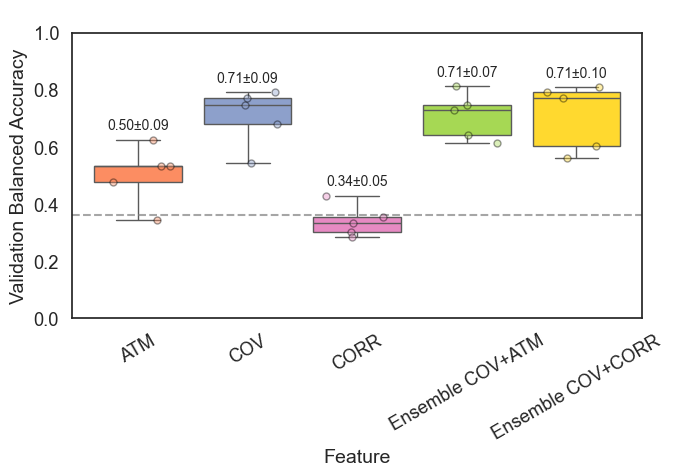

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import PathPatch
import os


# -------------------------------------------------------------------------------------------------
# TODO change here
# -------------------------------------------------------------------------------------------------
metric_to_plot = 'balanced_accuracy'     # use 'balanced_accuracy' for bal acc, or 'f1_macro'
ylabel = 'Balanced Accuracy'             # 'Balanced Accuracy' or 'F1 macro'
  
nodes = 50
# Insert the path where Results are stored
riemann_cov_atm_path = f'../../Results/num_nodes_{nodes}/logs/TSClassifier/metrics.json'
riemann_cov_cc_path = f'../../Results/num_nodes_{nodes}/logs/Corr_Mat/TSClassifier/metrics.json'

# Folder where to save the Figure produced
save_folder = "../../Images"
os.makedirs(save_folder, exist_ok=True)
# Name of the Figure produced
savename = f'Balanced_Accuracy_Riemann_nodes_{nodes}.png'  

def read_metrics_json(file_path, keys):
    with open(file_path, 'r') as f:
        data = json.load(f)

    metrics = ['accuracy', 'balanced_accuracy', 'f1_macro']
    results = {}

    for feature, subkeys in keys.items():
        results[feature] = {}
        for split, key in subkeys.items():
            results[feature][split] = {}
            for metric in metrics:
                values = [entry[metric] for entry in data[key]]
                mean = float(np.mean(values))
                std = float(np.std(values))
                results[feature][split][metric] = {
                    'values': values,
                    'mean': mean,
                    'std': std
                }

    return results

# Define keys for each feature combination
COV_ATM_keys = {
    'ensemble': {
        'train': 'train_metrics_ensemble',
        'validation': 'validation_metrics_ensemble'
    },
    'covariance_matrices': {
        'train': 'train_metrics_covariance_matrices',
        'validation': 'validation_metrics_covariance_matrices'
    },
    'atms': {
        'train': 'train_metrics_atms',
        'validation': 'validation_metrics_atms'
    }
}

COV_CC_keys = {
    'ensemble': {
        'train': 'train_metrics_ensemble',
        'validation': 'validation_metrics_ensemble'
    },
    'covariance_matrices': {
        'train': 'train_metrics_covariance_matrices',
        'validation': 'validation_metrics_covariance_matrices'
    },
    'correlation_matrices': {
        'train': 'train_metrics_correlation_matrices',
        'validation': 'validation_metrics_correlation_matrices'
    }
}

PSD_keys = {
    'ensemble': {
        'train': 'train_metrics_ensemble',
        'validation': 'validation_metrics_ensemble'
    },
    'psd_1': { # LDA or XGboost
        'train': 'train_metrics_psd_1',
        'validation': 'validation_metrics_psd_1'
    },
    'psd_2': { #SVM or Xgoost
        'train': 'train_metrics_psd_2',
        'validation': 'validation_metrics_psd_2'
    }
}


# Riemann


riemann_cov_atm_metrics_data = read_metrics_json(riemann_cov_atm_path, COV_ATM_keys)
riemann_cov_cc_metrics_data = read_metrics_json(riemann_cov_cc_path, COV_CC_keys)



# Define what to plot for each model
plot_items = [
    #('PSD', 'psd_1'),
    ('ATM', 'atms'),
    ('COV', 'covariance_matrices'),
    ('CORR', 'correlation_matrices'),
    ('Ensemble COV+ATM', 'ensemble'),
    ('Ensemble COV+CORR', 'ensemble')
]

# fig, axes = plt.subplots(2, 2, figsize=(14, 10))
# model_titles = ['LDA', 'SVM', 'XGBoost', 'Riemann (TS+KNN)']

# -------------------------------------------------------------------------------------------------
# TODO change here to personalize
# -------------------------------------------------------------------------------------------------

fig, axes = plt.subplots(1, 1, figsize=(7, 5))
model_titles = [' '] #['Riemann (TS+KNN)']#, 'LDA', 'SVM', 'XGBoost']
axes = np.array(axes)

# Riemann (TS+KNN) - no PSD
riemann_data = [
    ('ATM', riemann_cov_atm_metrics_data, 'atms'),
    ('COV', riemann_cov_atm_metrics_data, 'covariance_matrices'),
    ('CORR', riemann_cov_cc_metrics_data, 'correlation_matrices'),
    ('Ensemble COV+ATM', riemann_cov_atm_metrics_data, 'ensemble'),
    ('Ensemble COV+CORR', riemann_cov_cc_metrics_data, 'ensemble')
]


# -------------------------------------------------------------------------------------------------
# TODO change here to personalize what to plot
# -------------------------------------------------------------------------------------------------

#all_data = [riemann_data, lda_data, svc_data, xgb_data]
all_data = [riemann_data]

for ax, model_data, title in zip(axes.flat, all_data, model_titles):
    means = []
    stds = []
    labels = []
    all_values = []
    for item in model_data:
        label, metrics_data, feature = item
        vals = metrics_data[feature]['validation'][metric_to_plot]['values']
        mean = float(np.mean(vals))
        std = float(np.std(vals))
        means.append(mean)
        stds.append(std)
        labels.append(label)
        all_values.append(vals)

    # Prepare DataFrame for seaborn boxplot/stripplot

    # Each label is a feature, each value is a list of balanced accuracy scores
    df = pd.DataFrame({
        'Feature': np.repeat(labels, [len(v) for v in all_values]),
        'F1 Macro': np.concatenate(all_values),  # Use 'Balanced Accuracy' if you want to plot that instead
        'Model': title  # for possible hue, but here all same
    })

    # Custom colors for each feature
    feature_colors = sns.color_palette("Set2", 6)  # 6 distinct colors

    # Boxplot
    # For Riemann (no PSD), shift colors by 1 so ATM uses the second color, etc.
    if title == ' ':
        color_order = feature_colors[1:] + feature_colors[:1]  # Shift colors
    else:
        color_order = feature_colors

    sns.boxplot(
        data=df,
        x='Feature',
        y='F1 Macro', # Use 'Balanced Accuracy' if you want to plot that instead
        ax=ax,
        order=labels,
        whis=(0, 100),
        palette=color_order
    )
    box_patches = [p for p in ax.patches if isinstance(p, PathPatch)]
    for patch, color in zip(box_patches, color_order):
        patch.set_facecolor(color)

    # Stripplot (individual points)
    for i, label in enumerate(labels):
        # For Riemann (no PSD), shift colors by 1
        color_idx = i + 1 if title == ' ' else i
        sns.stripplot(
            data=df[df['Feature'] == label],
            x='Feature',
            y='F1 Macro',  # Use 'Balanced Accuracy' if you want to plot that instead
            ax=ax,
            order=[label],
            jitter=0.3,
            marker='o',
            alpha=0.4,
            edgecolor='black',
            linewidth=1,
            color=feature_colors[color_idx % len(color_order)]
        )

    # Plot mean and std
    for i, (mean, std) in enumerate(zip(means, stds)):
        # Find the maximum y-value for this feature's box
        y_max = max(all_values[i]) # Calculate the top of each box (bar) to place the text above it
        # Place the text slightly above the highest point (box/strip)
        ax.text(i, y_max + 0.025, f"{mean:.2f}±{std:.2f}", ha='center', va='bottom', fontsize=10)
    
    ax.set_xlim(ax.set_xlim()[0]-0.1,ax.set_xlim()[1]+0.1,)
    ax.set_title(title)
    ax.set_ylabel(f'Validation {ylabel}', fontsize=14) # Use 'Validation Balanced Accuracy' if you want to plot that instead
    ax.set_xlabel(f'Feature', fontsize=14) # Use 'Validation Balanced Accuracy' if you want to plot that instead
    ax.set_ylim(0, 1)
    ax.set_xticklabels(labels, rotation=30)

    # Add a dashed horizontal line at y=0.36
    if metric_to_plot == "balanced_accuracy":
        ax.axhline(0.36, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

#plt.title("Num nodes " + str(nodes))
plt.tight_layout()
plt.show()


# -------------------------------------------------------------------------------------------------
# TODO change here to personalize
# -------------------------------------------------------------------------------------------------
# Save the figure
fig.savefig(f'{save_folder}/{savename}', bbox_inches='tight')

## Fig. 5 - Plot comparison performances each classifier (PSD / COV + CORR)

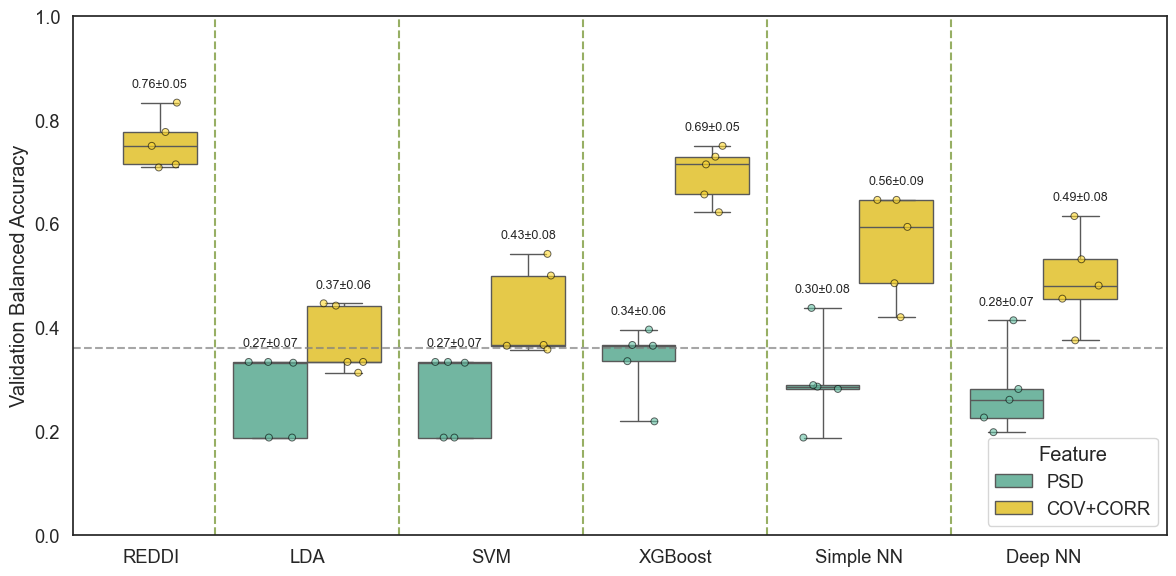

In [5]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import PathPatch

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
metric = "balanced_accuracy"
ylabel = "Validation Balanced Accuracy"
xlabel = ""

# Folder where Results are stored
nodes = 50
Results_Folder = f'../../Results'

# Folder where to save the Figure produced
save_folder = "../../Images"
os.makedirs(save_folder, exist_ok=True)
# Name of the Figure produced
savename = f'Benchmark_Balanced_Accuracy_nodes_{nodes}.png'   # Benchmark_Balanced_Accuracy.png, False (False if no Figure is saved)


sns.set(style="white", font_scale=1.2)

# Classical model paths
CLASSICAL_MODELS = {
    "LDA": {
        "PSD": (f"{Results_Folder}/logs/PSD/LinearDiscriminantAnalysis/metrics.json", "psd_1"),
        "Ensemble COV+CORR": (f"{Results_Folder}/num_nodes_{nodes}/logs/Corr_Mat/LinearDiscriminantAnalysis/metrics.json", "ensemble"),
    },
    "SVM": {
        "PSD": (f"{Results_Folder}/logs/PSD/LinearDiscriminantAnalysis/metrics.json", "psd_2"),
        "Ensemble COV+CORR": (f"{Results_Folder}/num_nodes_{nodes}/logs/Corr_Mat/SVC/metrics.json", "ensemble"),
    },
    "XGBoost": {
        "PSD": (f"{Results_Folder}/logs/PSD/XGBClassifier/metrics.json", "psd_1"),
        "Ensemble COV+CORR": (f"{Results_Folder}/num_nodes_{nodes}/logs/Corr_Mat/XGBClassifier/metrics.json", "ensemble"),
    }
}

# Riemann paths
RiemANN_MODEL = {
    "Riemann": {
    "Ensemble COV+CORR": (f"{Results_Folder}/num_nodes_{nodes}/logs/Corr_Mat/TSClassifier/metrics.json", "ensemble"),
    }
}



# NN paths
NN_BASE =  f"{Results_Folder}/num_nodes_{nodes}/NN"


if NN_BASE.split("/")[-1]=="logs":
    NN_file_name = "cv_scores.npy" 
elif metric == "balanced_accuracy":
    NN_file_name = "cv_balanced_accuracy_val.npy"
else:
    NN_file_name = "cv_f1_val.npy"

NN_FEATURES = {
    "PSD": "PSDs",
    "Ensemble COV+CORR": "COV+CORR"
}
NN_MODELS = ["SimpleNN", "DeepNN"]



# ------------------------------------------------------------------
# Utilities
# ------------------------------------------------------------------
def read_metrics_json(path, key):
    with open(path, "r") as f:
        data = json.load(f)
    return [entry[metric] for entry in data[key.replace("ensemble", "validation_metrics_ensemble")]]

# ------------------------------------------------------------------
# Collect data
# ------------------------------------------------------------------
rows = []

# Classical models
for model, feats in CLASSICAL_MODELS.items():
    for feature, (path, key) in feats.items():
        with open(path, "r") as f:
            data = json.load(f)
        vals = [x[metric] for x in data[f"validation_metrics_{key}"]]
        for v in vals:
            rows.append({
                "Model": model,
                "Feature": feature,
                "Score": v
            })

# Neural networks
for model in NN_MODELS:
    for feature, folder in NN_FEATURES.items():
        path = os.path.join(NN_BASE, folder, model, NN_file_name)
        uu = path
        if os.path.exists(path):
            scores = np.load(path)
            for v in scores:
                rows.append({
                    "Model": model,
                    "Feature": feature,
                    "Score": v
                })

# Riemann
for model, feats in RiemANN_MODEL.items():
    for feature, (path, key) in feats.items():
        with open(path, "r") as f:
            data = json.load(f)
        vals = [x[metric] for x in data[f"validation_metrics_{key}"]]
        for v in vals:
            rows.append({
                "Model": model,
                "Feature": feature,
                "Score": v
            })

df = pd.DataFrame(rows)

# ------------------------------------------------------------------
# Plot
# ------------------------------------------------------------------
plt.figure(figsize=(12,6))
feature_colors = sns.color_palette("Set2", 6)  # 6 distinct colors
palette = {
    "PSD": feature_colors[0],
    "Ensemble COV+CORR": feature_colors[-1],
}

order = ["Riemann", "LDA", "SVM", "XGBoost", "SimpleNN", "DeepNN"]

ax = sns.boxplot(
    data=df,
    x="Model",
    y="Score",
    hue="Feature",
    order=order,
    hue_order=["PSD", "Ensemble COV+CORR"],
    whis=(0, 100),
    palette=palette
)

sns.stripplot(
    data=df,
    x="Model",
    y="Score",
    hue="Feature",
    order=order,
    hue_order=["PSD", "Ensemble COV+CORR"],
    dodge=True,
    jitter=0.25,
    alpha=0.6,
    linewidth=0.7,
    edgecolor="black",
    palette=palette
)

# Remove duplicated legends
handles, labels = ax.get_legend_handles_labels()
#ax.legend(handles[:2], labels[:2], title="Feature", loc="lower right")
ax.legend(handles[:2], ["PSD", "COV+CORR"], title="Feature", loc="lower right")

# Mean ± std annotations
for i, model in enumerate(order):
    for j, feature in enumerate(["PSD", "Ensemble COV+CORR"]):
        vals = df[(df.Model == model) & (df.Feature == feature)]["Score"].values
        if len(vals) == 0:
            continue
        mean, std = np.mean(vals), np.std(vals)
        x = i + (-0.2 if feature == "PSD" else 0.2)
        y = np.max(vals) + 0.03
        ax.text(x, y, f"{mean:.2f}±{std:.2f}", ha="center", fontsize=9)

new_labels = [
    "REDDI",
    "LDA",
    "SVM",
    "XGBoost",
    "Simple NN",
    "Deep NN",
]


new_positions = [i for i in range(len(new_labels))]
new_positions[0]+=0.15

ax.set_xticks(new_positions)
ax.set_xticklabels(new_labels)



ax.vlines([0.5,1.5,2.5,3.5,4.5],0,1,linestyles="--",color="olivedrab", alpha=0.7)
ax.set_ylabel(ylabel)
ax.set_xlabel(xlabel=xlabel, labelpad=15)
ax.set_ylim(0, 1)
if metric == "balanced_accuracy":
    ax.axhline(0.36, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)
#plt.title(f"Num nodes {nodes}", fontsize=14)
plt.tight_layout()
if savename:
    plt.savefig(f"{save_folder}/{savename}", dpi=300)
plt.show()


## Supplementary - All benchmark comparison (validation + training peformances) (F1 Macro + Balanced Accuracy)

C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\2802591922.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(val_labels, rotation=30)
C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\2802591922.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(val_labels, rotation=30)
C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\2802591922.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(val_labels, rotation=30)
C:\Users\Giovanni\AppData\Local\Temp\ipykernel_284\2802591922.py:272: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(val_labels, rotation=30)
C:\Users\Giovanni\AppDat

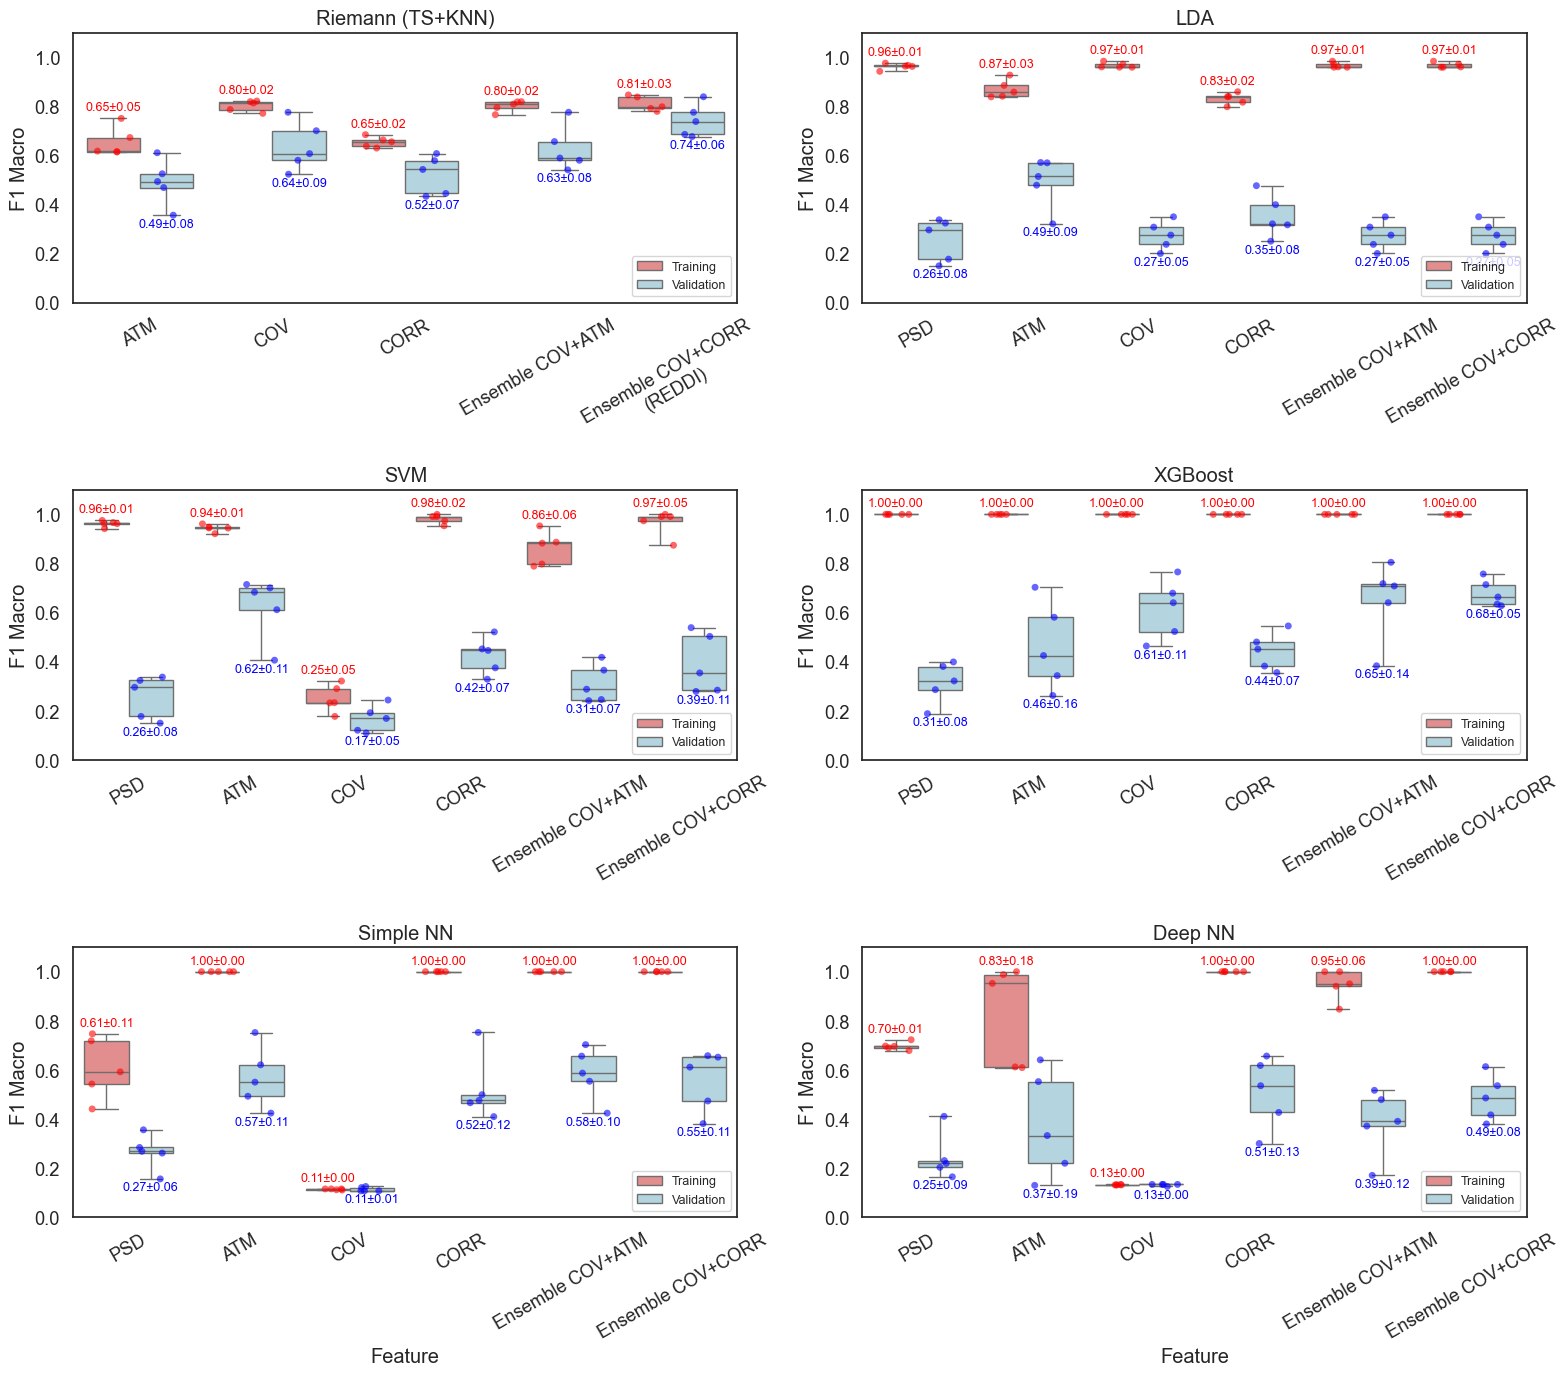

In [ ]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# ------------------------------------------------------------------
# Configuration
# ------------------------------------------------------------------
metric_to_plot = 'balanced_accuracy'             # 'balanced_accuracy' or 'f1_macro'
nodes = 50
savename = f'Benchmark_train_val_Balanced_Accuracy_nodes_{nodes}'  # False or 'Benchmark_train_val_Balanced_Accuracy' or 'Benchmark_train_val_F1_Macro'


# Folder where Results are stored

Results_Folder = f'../../Results/num_nodes_{nodes}'
Results_Folder_PSD = "/".join(Results_Folder.split("/")[:-1])

# Folder where to save the Figure produced
save_folder = "../../Images"
os.makedirs(save_folder, exist_ok=True)
# Name of the Figure produced



ylabel = 'Balanced Accuracy' if metric_to_plot == 'balanced_accuracy' else 'F1 Macro'
sns.set(style="white", font_scale=1.2)

# ------------------------------------------------------------------
# JSON reader for classical / Riemann
# ------------------------------------------------------------------
def read_metrics_json(file_path, keys):
    with open(file_path, 'r') as f:
        data = json.load(f)

    metrics = ['accuracy', 'balanced_accuracy', 'f1_macro']
    results = {}

    for feature, subkeys in keys.items():
        results[feature] = {}
        for split, key in subkeys.items():
            results[feature][split] = {}
            for metric in metrics:
                values = [entry[metric] for entry in data[key]]
                results[feature][split][metric] = {
                    'values': values,
                    'mean': float(np.mean(values)),
                    'std': float(np.std(values))
                }
    return results

# ------------------------------------------------------------------
# Keys
# ------------------------------------------------------------------
COV_ATM_keys = {
    'ensemble': {'train': 'train_metrics_ensemble', 'validation': 'validation_metrics_ensemble'},
    'covariance_matrices': {'train': 'train_metrics_covariance_matrices', 'validation': 'validation_metrics_covariance_matrices'},
    'atms': {'train': 'train_metrics_atms', 'validation': 'validation_metrics_atms'}
}

COV_CC_keys = {
    'ensemble': {'train': 'train_metrics_ensemble', 'validation': 'validation_metrics_ensemble'},
    'covariance_matrices': {'train': 'train_metrics_covariance_matrices', 'validation': 'validation_metrics_covariance_matrices'},
    'correlation_matrices': {'train': 'train_metrics_correlation_matrices', 'validation': 'validation_metrics_correlation_matrices'}
}

PSD_keys = {
    'ensemble': {'train': 'train_metrics_ensemble', 'validation': 'validation_metrics_ensemble'},
    'psd_1': {'train': 'train_metrics_psd_1', 'validation': 'validation_metrics_psd_1'},
    'psd_2': {'train': 'train_metrics_psd_2', 'validation': 'validation_metrics_psd_2'}
}
f'{Results_Folder}'
# ------------------------------------------------------------------
# Paths
# ------------------------------------------------------------------
lda_cov_atm_path = f'{Results_Folder}/logs/LinearDiscriminantAnalysis/metrics.json'
lda_cov_cc_path = f'{Results_Folder}/logs/Corr_Mat/LinearDiscriminantAnalysis/metrics.json'
lda_psd_path = f'{Results_Folder_PSD}/logs/PSD/LinearDiscriminantAnalysis/metrics.json'

svc_cov_atm_path = f'{Results_Folder}/logs/SVC/metrics.json'
svc_cov_cc_path = f'{Results_Folder}/logs/Corr_Mat/SVC/metrics.json'

xgb_cov_atm_path = f'{Results_Folder}/logs/XGBClassifier/metrics.json'
xgb_cov_cc_path = f'{Results_Folder}/logs/Corr_Mat/XGBClassifier/metrics.json'
xgb_psd_path = f'{Results_Folder_PSD}/logs/PSD/XGBClassifier/metrics.json'

riemann_cov_atm_path = f'{Results_Folder}/logs/TSClassifier/metrics.json'
riemann_cov_cc_path = f'{Results_Folder}/logs/Corr_Mat/TSClassifier/metrics.json'

# ------------------------------------------------------------------
# Load classical / Riemann metrics
# ------------------------------------------------------------------
lda_cov_atm_metrics_data = read_metrics_json(lda_cov_atm_path, COV_ATM_keys)
lda_cov_cc_metrics_data = read_metrics_json(lda_cov_cc_path, COV_CC_keys)
lda_psd_metrics_data = read_metrics_json(lda_psd_path, PSD_keys)

svc_cov_atm_metrics_data = read_metrics_json(svc_cov_atm_path, COV_ATM_keys)
svc_cov_cc_metrics_data = read_metrics_json(svc_cov_cc_path, COV_CC_keys)

xgb_cov_atm_metrics_data = read_metrics_json(xgb_cov_atm_path, COV_ATM_keys)
xgb_cov_cc_metrics_data = read_metrics_json(xgb_cov_cc_path, COV_CC_keys)
xgb_psd_metrics_data = read_metrics_json(xgb_psd_path, PSD_keys)

riemann_cov_atm_metrics_data = read_metrics_json(riemann_cov_atm_path, COV_ATM_keys)
riemann_cov_cc_metrics_data = read_metrics_json(riemann_cov_cc_path, COV_CC_keys)

# ------------------------------------------------------------------
# Model data definitions
# ------------------------------------------------------------------
lda_data = [
    ('PSD', lda_psd_metrics_data, 'psd_1'),
    ('ATM', lda_cov_atm_metrics_data, 'atms'),
    ('COV', lda_cov_atm_metrics_data, 'covariance_matrices'),
    ('CORR', lda_cov_cc_metrics_data, 'correlation_matrices'),
    ('Ensemble COV+ATM', lda_cov_atm_metrics_data, 'ensemble'),
    ('Ensemble COV+CORR', lda_cov_cc_metrics_data, 'ensemble')
]

svc_data = [
    ('PSD', lda_psd_metrics_data, 'psd_2'),
    ('ATM', svc_cov_atm_metrics_data, 'atms'),
    ('COV', svc_cov_atm_metrics_data, 'covariance_matrices'),
    ('CORR', svc_cov_cc_metrics_data, 'correlation_matrices'),
    ('Ensemble COV+ATM', svc_cov_atm_metrics_data, 'ensemble'),
    ('Ensemble COV+CORR', svc_cov_cc_metrics_data, 'ensemble')
]

xgb_data = [
    ('PSD', xgb_psd_metrics_data, 'psd_1'),
    ('ATM', xgb_cov_atm_metrics_data, 'atms'),
    ('COV', xgb_cov_atm_metrics_data, 'covariance_matrices'),
    ('CORR', xgb_cov_cc_metrics_data, 'correlation_matrices'),
    ('Ensemble COV+ATM', xgb_cov_atm_metrics_data, 'ensemble'),
    ('Ensemble COV+CORR', xgb_cov_cc_metrics_data, 'ensemble')
]

riemann_data = [
    ('ATM', riemann_cov_atm_metrics_data, 'atms'),
    ('COV', riemann_cov_atm_metrics_data, 'covariance_matrices'),
    ('CORR', riemann_cov_cc_metrics_data, 'correlation_matrices'),
    ('Ensemble COV+ATM', riemann_cov_atm_metrics_data, 'ensemble'),
    ('Ensemble COV+CORR\n(REDDI)', riemann_cov_cc_metrics_data, 'ensemble')
]

# ------------------------------------------------------------------
# Neural Networks
# ------------------------------------------------------------------
# look in Result_Folder/NN/NN_Features/NN_MODELS/file_name.npy
NN_BASE = f'{Results_Folder}/NN'
NN_FEATURES = {"PSD": "PSDs", 'ATM':'ATM', 'COV':'Covariance', 'CORR':'Correlation', 'Ensemble COV+ATM': 'COV+ATM', "Ensemble COV+CORR": "COV+CORR"}
NN_MODELS = ["SimpleNN", "DeepNN"]

if metric_to_plot == "balanced_accuracy":
    NN_VAL_FILE = "cv_balanced_accuracy_val.npy"
    NN_TRAIN_FILE = "cv_balanced_accuracy_train.npy"
else:
    NN_VAL_FILE = "cv_f1_val.npy"
    NN_TRAIN_FILE = "cv_f1_train.npy"

def load_nn_data(model_name):
    metrics = {}
    for label, folder in NN_FEATURES.items():
        val_path = os.path.join(NN_BASE,folder,  model_name, NN_VAL_FILE)
        train_path = os.path.join(NN_BASE,folder,  model_name, NN_TRAIN_FILE)
        if os.path.exists(val_path) and os.path.exists(train_path):
            metrics[label] = {
                'validation': {metric_to_plot: {'values': np.load(val_path)}},
                'train': {metric_to_plot: {'values': np.load(train_path)}}
            }
    return metrics

simple_nn_metrics = load_nn_data("SimpleNN")
deep_nn_metrics = load_nn_data("DeepNN")

simple_nn_data = [(k, simple_nn_metrics, k) for k in simple_nn_metrics]
deep_nn_data = [(k, deep_nn_metrics, k) for k in deep_nn_metrics]

# ------------------------------------------------------------------
# ALL DATA & TITLES (3x2 layout)
# ------------------------------------------------------------------
all_data = [
    riemann_data, lda_data, svc_data,
    xgb_data, simple_nn_data, deep_nn_data
]

model_titles = [
    'Riemann (TS+KNN)', 'LDA', 'SVM',
    'XGBoost', 'Simple NN', 'Deep NN'
]

# ------------------------------------------------------------------
# Plotting (UNCHANGED LOGIC)
# ------------------------------------------------------------------
fig2, axes2 = plt.subplots(3, 2, figsize=(16, 14))
axes2 = axes2.flatten()

for ax, model_data, title in zip(axes2, all_data, model_titles):
    val_labels, val_values, train_values = [], [], []

    for label, metrics_data, feature in model_data:
        val_vals = metrics_data[feature]['validation'][metric_to_plot]['values']
        train_vals = metrics_data[feature]['train'][metric_to_plot]['values']
        val_labels.append(label)
        val_values.append(val_vals)
        train_values.append(train_vals)

    all_features, all_scores, all_splits = [], [], []
    for i, label in enumerate(val_labels):
        all_features += [label] * len(val_values[i])
        all_scores += list(val_values[i])
        all_splits += ['Validation'] * len(val_values[i])

        all_features += [label] * len(train_values[i])
        all_scores += list(train_values[i])
        all_splits += ['Training'] * len(train_values[i])

    df = pd.DataFrame({'Feature': all_features, ylabel: all_scores, 'Split': all_splits})

    sns.boxplot(
        data=df, x='Feature', y=ylabel, hue='Split',
        order=val_labels, hue_order=['Training', 'Validation'],
        ax=ax, whis=(0, 100), palette=['lightcoral', 'lightblue']
    )

    sns.stripplot(
        data=df, x='Feature', y=ylabel, hue='Split',
        order=val_labels, hue_order=['Training', 'Validation'],
        ax=ax, dodge=True, jitter=0.3, alpha=0.6,
        palette=['red', 'blue']
    )
    # --------------------------------------------------
    # Calculate and display means ± stds
    # --------------------------------------------------
    for i, label in enumerate(val_labels):
        val_mean = float(np.mean(val_values[i]))
        val_std = float(np.std(val_values[i]))
        train_mean = float(np.mean(train_values[i]))
        train_std = float(np.std(train_values[i]))

        y_max_train = max(train_values[i])
        y_min_val = min(val_values[i])

        # Training (red, above)
        ax.text(
            i - 0.2,
            y_max_train + 0.02,
            f"{train_mean:.2f}±{train_std:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='red'
        )

        # Validation (blue, below)
        ax.text(
            i + 0.2,
            y_min_val - 0.06,
            f"{val_mean:.2f}±{val_std:.2f}",
            ha='center',
            va='bottom',
            fontsize=9,
            color='blue'
        )

    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles[:2], labels[:2], loc='lower right', fontsize=9)

    ax.set_title(title)
    ax.set_ylim(0, 1.1)
    ax.set_xticklabels(val_labels, rotation=30)
    if metric_to_plot == "balanced_accuracy":
        ax.axhline(0.36, color='gray', linestyle='--', linewidth=1.5, alpha=0.7)

for num,ax in enumerate(axes2):
    if num < 4:
        ax.set_xlabel("")

#plt.title(f"Num nodes {nodes}", fontsize=14)
plt.tight_layout()
plt.show()
if savename:
    fig2.savefig(f'{save_folder}/{savename}.png', bbox_inches='tight', dpi=300)
